# Regression

using california housing dataset (large version)

using keras callbacks

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import datasets, layers, Sequential
from keras import callbacks

## 1- Data Preparation

In [59]:
(train_data, train_targets), (test_data, test_targets) = datasets.california_housing.load_data()

In [60]:
print(train_data.shape)
print(train_targets.shape)
print(test_data.shape)
print(test_targets.shape)

(16512, 8)
(16512,)
(4128, 8)
(4128,)


### Pre-processing

In [61]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

x_train = (train_data - mean)/std
x_test = (test_data - mean)/std

In [62]:
y_train = train_targets / 10_000
y_test = test_targets / 10_000

## 2- Model Design

In [63]:
def get_model():
    model = Sequential([
        layers.Input(shape=(x_train.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model

model = get_model()
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

## 3- Training

### Callbacks

In [64]:
model_chkpnt = callbacks.ModelCheckpoint(
    'model.keras',
    monitor='val_loss',
    save_best_only=True,
)

csv_logger = callbacks.CSVLogger('training.csv')
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3
)

my_callbacks = [model_chkpnt, csv_logger, reduce_lr, early_stop]

In [65]:
model = get_model()

In [66]:
history = model.fit(x_train, y_train,
                    epochs=50, batch_size=64,
                    validation_split=0.2,
                    callbacks=my_callbacks)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 222.4251 - mean_absolute_error: 11.0563 - val_loss: 72.6277 - val_mean_absolute_error: 6.2083 - learning_rate: 0.0010
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 61.4141 - mean_absolute_error: 5.6327 - val_loss: 49.4133 - val_mean_absolute_error: 5.0895 - learning_rate: 0.0010
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 46.4640 - mean_absolute_error: 4.8569 - val_loss: 42.9046 - val_mean_absolute_error: 4.6380 - learning_rate: 0.0010
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 42.2538 - mean_absolute_error: 4.6312 - val_loss: 41.0449 - val_mean_absolute_error: 4.5911 - learning_rate: 0.0010
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40.4956 - mean_absolute_error: 4.5216 - val_loss: 39.9590 - val_mean_absolute_error: 4.4190 - learning_rate: 0.0010
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39.2780 - mean_absolute_error: 4.4362 - val_loss: 39.2716 

## 4- Evaluation

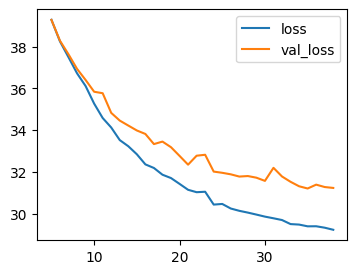

In [67]:
history_df = pd.DataFrame(history.history)
history_df[['loss', 'val_loss']][5:].plot(figsize=(4,3))
plt.show()

In [68]:
mse, mae = model.evaluate(x_test, y_test, verbose=0)
print('MSE:', mse*10_000)
print('MAE:', mae*10_000)

MSE: 313842.04864501953
MAE: 38118.6580657959


## 5- Save the Model and/or Weights

In [69]:
# Save model's Structure (without weights)
model_json = model.to_json()

In [70]:
loaded_model = keras.models.model_from_json(model_json)

In [71]:
mse, mae = loaded_model.evaluate(x_test, y_test, verbose=0)
print('MSE:', mse*10_000)
print('MAE:', mae*10_000)

MSE: 5634982.91015625
MAE: 207473.08731079102


In [72]:
# Save Model Weights
model.save_weights('model_weights.weights.h5')

In [73]:
loaded_model.load_weights('model_weights.weights.h5')

In [74]:
mse, mae = loaded_model.evaluate(x_test, y_test, verbose=0)
print('MSE:', mse*10_000)
print('MAE:', mae*10_000)

MSE: 313842.04864501953
MAE: 38118.6580657959


In [75]:
# Save model and weights together
model.save('model_saved.keras')

In [76]:
loaded_model2 = keras.models.load_model('model_saved.keras')

In [77]:
mse, mae = loaded_model2.evaluate(x_test, y_test, verbose=0)
print('MSE:', mse*10_000)
print('MAE:', mae*10_000)

MSE: 313842.04864501953
MAE: 38118.6580657959


In [86]:
# Load and test the checkpoint (with the best val_loss)
loaded_checkpoint = keras.models.load_model('model.keras')

In [87]:
mse, mae = loaded_checkpoint.evaluate(x_test, y_test, verbose=0)
print('MSE:', mse*10_000)
print('MAE:', mae*10_000)

MSE: 313759.3078613281
MAE: 38352.463245391846


## 6- Continue previous training

In [88]:
# Reduce the initial LR
loaded_checkpoint.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
                          loss='mse',
                          metrics=['mae'])

In [89]:
csv_log = pd.read_csv('training.csv')
stopped_at = len(csv_log)

In [90]:
model_chkpnt = callbacks.ModelCheckpoint(
    'model2.keras',
    monitor='val_loss',
    save_best_only=True,
)

csv_logger = callbacks.CSVLogger('training2.csv')
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

my_callbacks = [model_chkpnt, csv_logger, reduce_lr, early_stop]

In [91]:
history2 = model.fit(x_train, y_train,
                     initial_epoch=stopped_at,
                     epochs=90, batch_size=64,
                     validation_split=0.2,
                     callbacks=my_callbacks)

Epoch 40/90
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29.0527 - mean_absolute_error: 3.7397 - val_loss: 31.1297 - val_mean_absolute_error: 3.8126 - learning_rate: 6.2500e-05
Epoch 41/90
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29.0585 - mean_absolute_error: 3.7397 - val_loss: 31.1105 - val_mean_absolute_error: 3.8233 - learning_rate: 6.2500e-05
Epoch 42/90
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29.0476 - mean_absolute_error: 3.7389 - val_loss: 31.1099 - val_mean_absolute_error: 3.8147 - learning_rate: 6.2500e-05
Epoch 43/90
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29.0442 - mean_absolute_error: 3.7363 - val_loss: 31.1179 - val_mean_absolute_error: 3.8177 - learning_rate: 6.2500e-05
Epoch 44/90
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29.0248 - mean_absolute_error: 3.7371 - val_loss: 31.1753 - val_mean_absolute_error: 3.8366 - learning_rate: 6.2500e-05
Epoch 45/90
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 28.9859 - mean_absolute_error: 3.7

### Plot the histories of both trainings together

In [92]:
history_df2 = pd.DataFrame(history2.history)

In [93]:
history_df.head()

,loss,mean_absolute_error,val_loss,val_mean_absolute_error,learning_rate
0,222.425140,11.056252,72.627678,6.208348,0.001
1,61.414112,5.632689,49.413311,5.089456,0.001
2,46.464039,4.856924,42.904552,4.637976,0.001
3,42.253780,4.631175,41.044949,4.591105,0.001
4,40.495564,4.521639,39.959003,4.418956,0.001


In [94]:
history_df2.head()

,loss,mean_absolute_error,val_loss,val_mean_absolute_error,learning_rate
0,29.052723,3.739744,31.129730,3.812628,0.000063
1,29.058546,3.739701,31.110506,3.823254,0.000063
2,29.047606,3.738949,31.109888,3.814657,0.000063
3,29.044224,3.736253,31.117857,3.817677,0.000063
4,29.024761,3.737053,31.175266,3.836563,0.000063


In [99]:
history_df_totall = pd.concat([history_df, history_df2],
                             ignore_index=True)

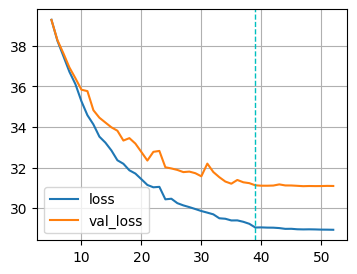

In [110]:
history_df_totall[['loss', 'val_loss']][5:].plot(figsize=(4,3))
plt.axvline(39, color='c', linestyle='--', linewidth=1)
plt.grid(True)
plt.show()